# Multi-Class Prediction of Obesity Risk using the Playground Series S4E2 Dataset

Competition: https://www.kaggle.com/competitions/playground-series-s4e2/overview

This notebook builds four classification models to predict `NObeyesdad` (7-level obesity risk category) from demographic and lifestyle features:
1. **Multinomial Logistic Regression** (with L2 regularization)
2. **Linear Discriminant Analysis (LDA)**
3. **Gaussian Naive Bayes**
4. **Support Vector Machine (SVM)**

Each model is trained using the labeled training data, evaluated on a stratified validation sample, interpreted, and then refitted on the complete training dataset to generate four separate Kaggle submission files.

## 1. Setup and Data Loading

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis
from sklearn.base import clone
from sklearn.model_selection import (train_test_split, cross_validate,
                                     StratifiedKFold, GridSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             f1_score)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42

In [2]:
from pathlib import Path
import pandas as pd

def locate_file(filename):
    matches = sorted(
        path
        for path in Path("/kaggle/input").rglob(filename)
        if path.is_file()
    )

    if not matches:
        raise FileNotFoundError(
            f"No actual file named '{filename}' was found. "
            "Use Kaggle's Add Input option to attach the competition dataset."
        )

    # Display matches when multiple datasets contain the same filename
    if len(matches) > 1:
        print(f"Multiple matches found for {filename}:")
        for i, path in enumerate(matches):
            print(f"  [{i}] {path}")
        print(f"Using: {matches[0]}")

    return matches[0]


train_path = locate_file("train.csv")
test_path = locate_file("test.csv")
sample_path = locate_file("sample_submission.csv")

print("Train:", train_path)
print("Test:", test_path)
print("Sample submission:", sample_path)

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

display(train.head())

Train: /kaggle/input/datasets/maseratiurm/multi-class-prediction-of-obesity-risk/train.csv/train.csv
Test: /kaggle/input/datasets/maseratiurm/multi-class-prediction-of-obesity-risk/test.csv/test.csv
Sample submission: /kaggle/input/datasets/maseratiurm/multi-class-prediction-of-obesity-risk/sample_submission.csv
Training shape: (20758, 18)
Testing shape: (13840, 17)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
#import pandas as pd

#train = pd.read_csv(train_path)
#test = pd.read_csv(test_path)
#sample_submission = pd.read_csv(sample_path)

### Data quality and class balance

We check for missing values, duplicate observations, unique identifiers, and target balance before modeling. The largest-to-smallest class ratio supplements the visual class-count comparison.

In [4]:
print("Missing values in training data:", train.isna().sum().sum())
print("Missing values in test data:", test.isna().sum().sum())
print("Duplicate training rows excluding ID:", train.drop(columns='id').duplicated().sum())
print("Unique training IDs:", train['id'].is_unique)
print("Unique test IDs:", test['id'].is_unique)

class_distribution = train['NObeyesdad'].value_counts().rename_axis('Obesity Class').to_frame('Frequency')
class_distribution['Percentage'] = 100 * class_distribution['Frequency'] / len(train)
display(class_distribution.round(2))
ratio = class_distribution['Frequency'].max() / class_distribution['Frequency'].min()
print(f"Largest-to-smallest class ratio: {ratio:.2f}")


Missing values in training data: 0
Missing values in test data: 0
Duplicate training rows excluding ID: 0
Unique training IDs: True
Unique test IDs: True


,Frequency,Percentage
Obesity Class,,
Obesity_Type_III,4046,19.49
Obesity_Type_II,3248,15.65
Normal_Weight,3082,14.85
Obesity_Type_I,2910,14.02
Insufficient_Weight,2523,12.15
Overweight_Level_II,2522,12.15
Overweight_Level_I,2427,11.69


Largest-to-smallest class ratio: 1.67


**Data-quality interpretation:** The data contain no missing values or duplicate feature–target rows, and the identifiers are unique. The largest-to-smallest class ratio is approximately 1.67, indicating a moderate rather than severe class imbalance that can still distort classical decision boundaries if left unaddressed (He & Garcia, 2009). To mitigate this, we used a stratified split to preserve this exact distribution in the validation sample, ensuring stable, representation-preserving performance metrics (Joseph, 2021; May et al., 2010).

## 2. Exploratory Data Analysis

The target `NObeyesdad` has 7 roughly ordered levels (Insufficient, Normal, Overweight I/II, Obesity I/II/III). Features include numeric (Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE) and categorical (Gender, family history, eating/smoking/transport habits).

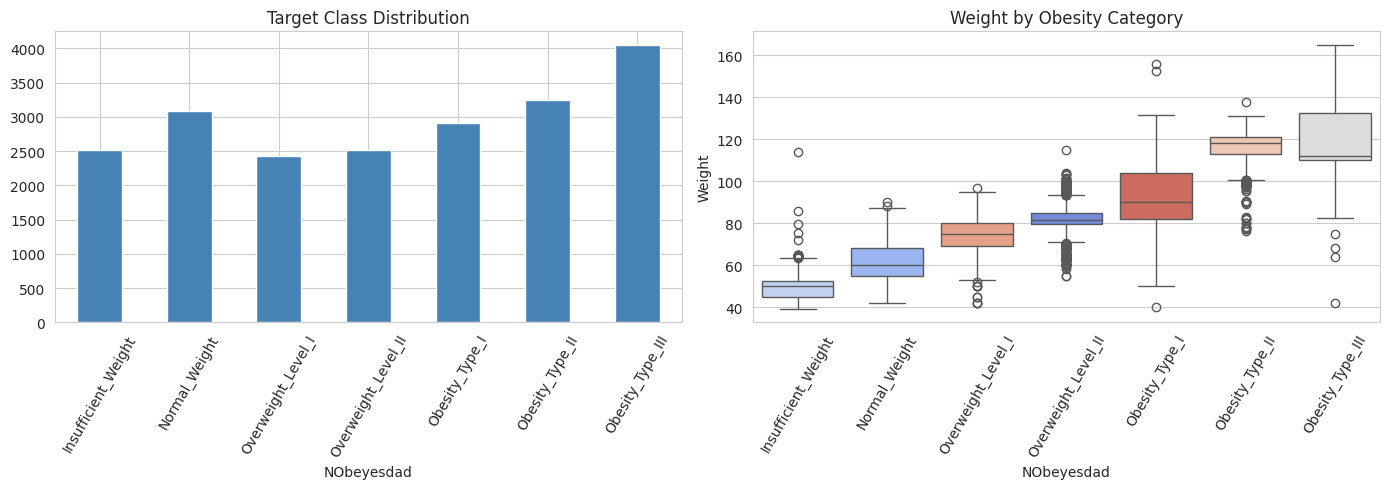

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I','Overweight_Level_II',
         'Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']
train['NObeyesdad'].value_counts().reindex(order).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Target Class Distribution')
axes[0].set_xlabel('NObeyesdad')
axes[0].tick_params(axis='x', rotation=60)

sns.boxplot(data=train, x='NObeyesdad', y='Weight', order=order, ax=axes[1], hue='NObeyesdad', legend=False, palette='coolwarm')
axes[1].set_title('Weight by Obesity Category')
axes[1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

The classes exhibit a moderate imbalance rather than a severe one. Among the categories, `Obesity_Type_III` is the most prevalent, while `Overweight_Level_I` is the least common. Generally, weight increases across the ordered categories and is expected to be an important predictor. However, interpret its influence alongside height, as obesity categories are closely associated with BMI.


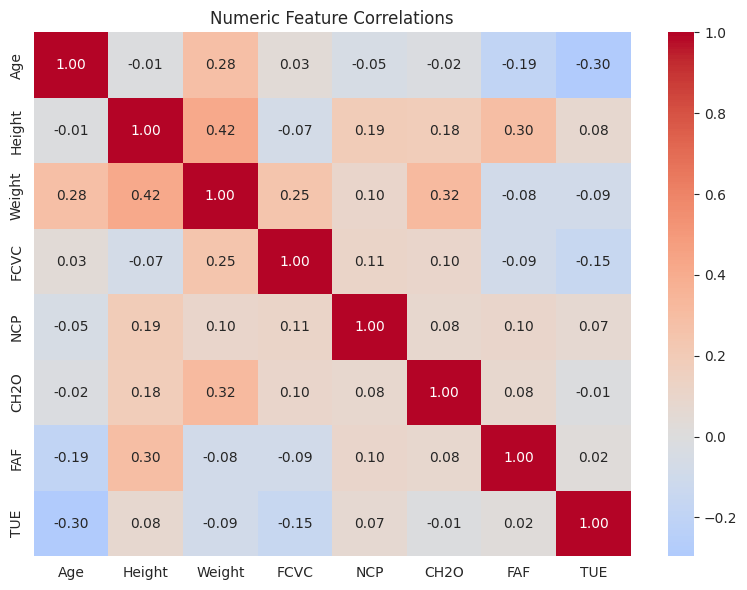

In [6]:
numeric_cols = ['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE']
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(train[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Numeric Feature Correlations')
plt.tight_layout()
plt.show()

The heatmap does not show extreme pairwise correlations among the numeric predictors. Because pairwise correlations alone cannot rule out multicollinearity involving several predictors, a standardized matrix condition number is also calculated below to robustly detect multicollinearity.

### Logistic regression assumption diagnostics

Multinomial logistic regression relies on several key assumptions: independent observations, mutually exclusive outcome classes, no severe multicollinearity, and approximately linear relationships between continuous predictors and the log-odds of each class. The independence of observations depends on the competition's sampling design and cannot be determined solely from the data table. To evaluate collinearity, the condition number can be used, and binned empirical log-odds plots can help assess the functional form of the relationships.

Standardized design-matrix condition number: 2.23


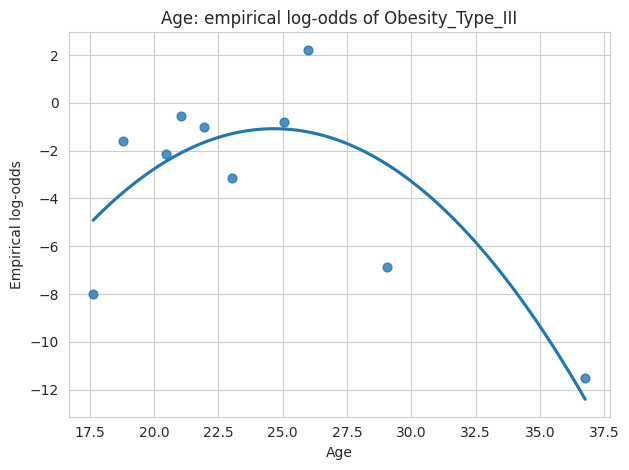

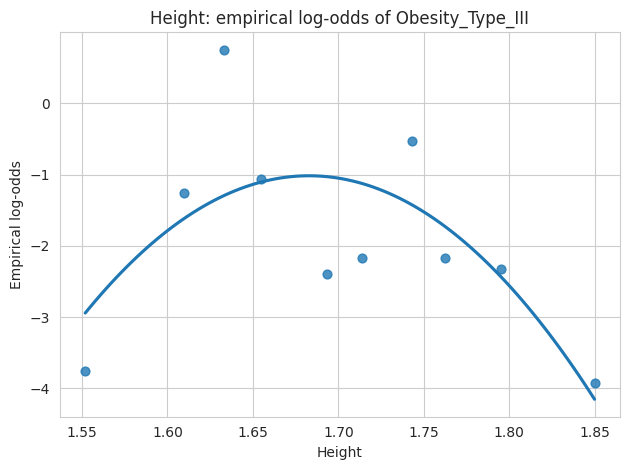

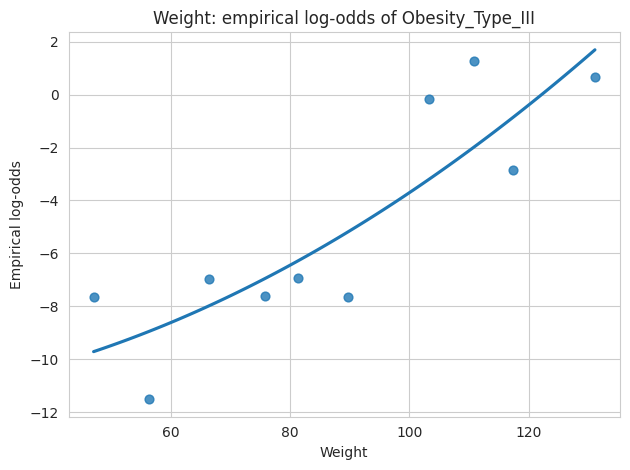

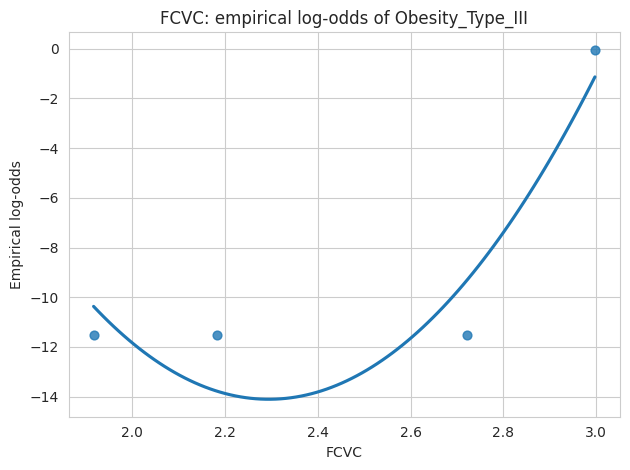

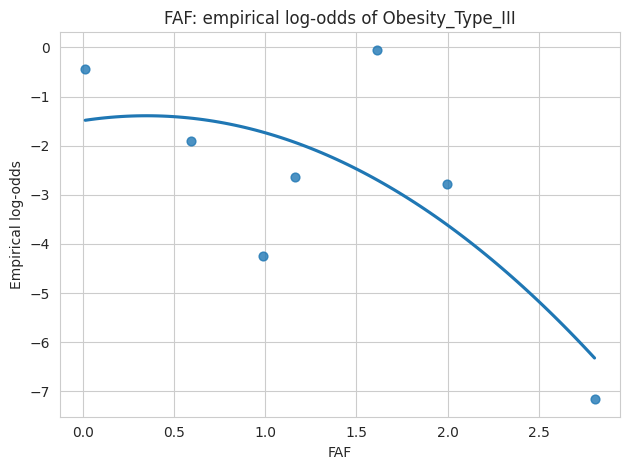

In [7]:
X_condition = StandardScaler().fit_transform(train[numeric_cols])
condition_number = np.linalg.cond(X_condition)
print(f"Standardized design-matrix condition number: {condition_number:.2f}")

def plot_empirical_log_odds(data, feature, target_class, bins=10):
    temp = data[[feature, 'NObeyesdad']].dropna().copy()
    temp['class_indicator'] = (temp['NObeyesdad'] == target_class).astype(int)
    temp['bin'] = pd.qcut(temp[feature], q=bins, duplicates='drop')
    summary = temp.groupby('bin', observed=True).agg(
        feature_mean=(feature, 'mean'), probability=('class_indicator', 'mean'))
    p = summary['probability'].clip(1e-5, 1-1e-5)
    summary['log_odds'] = np.log(p/(1-p))
    sns.regplot(data=summary, x='feature_mean', y='log_odds', order=2, ci=None,
                scatter_kws={'s':40})
    plt.title(f"{feature}: empirical log-odds of {target_class}")
    plt.xlabel(feature); plt.ylabel('Empirical log-odds'); plt.tight_layout(); plt.show()

for variable in ['Age', 'Height', 'Weight', 'FCVC', 'FAF']:
    plot_empirical_log_odds(train, variable, 'Obesity_Type_III')


**Interpretation:** A modest condition number suggests the absence of severe multicollinearity. Curvature in the empirical log-odds plots indicates that the multinomial model's linearity assumption is only approximate, supporting a comparison with a nonlinear classifier. These plots are diagnostic tools, not formal proof of the assumption.

## 3. Preprocessing

- **Target**: label-encoded as integers 0–6 for modeling, then decoded back to strings for the submission file.
- **Binary categoricals** (`Gender`, `family_history_with_overweight`, `FAVC`, `SMOKE`, `SCC`): ordinal/binary encoded.
- **Ordinal categoricals** (`CAEC`, `CALC`: frequency scales `no < Sometimes < Frequently < Always`): encoded to preserve their natural order rather than one-hot, since they represent an ordered frequency.
- **Nominal categorical** (`MTRANS`, mode of transport, no natural order): one-hot encoded.
- **Numeric features**: standardized (zero mean, unit variance) — this matters for LDA, Naive Bayes, and especially SVM, which are sensitive to feature scale.
- **Identifier**: id was excluded because it is a row identifier rather than a substantive predictor.

In [8]:
le_target = LabelEncoder()
y = le_target.fit_transform(train['NObeyesdad'])
print(dict(zip(le_target.classes_, range(len(le_target.classes_)))))

X = train.drop(columns=['id','NObeyesdad'])
X_test_final = test.drop(columns=['id'])

binary_cols = ['Gender','family_history_with_overweight','FAVC','SMOKE','SCC']
ordinal_cols = ['CAEC','CALC']
nominal_cols = ['MTRANS']
numeric_cols = ['Age','Height','Weight','FCVC','NCP','CH2O','FAF','TUE']

freq_order = ['no','Sometimes','Frequently','Always']

def encode(df):
    df = df.copy()
    df['Gender'] = (df['Gender'] == 'Male').astype(int)
    for c in ['family_history_with_overweight','FAVC','SMOKE','SCC']:
        df[c] = (df[c] == 'yes').astype(int)
    for c in ordinal_cols:
        df[c] = df[c].apply(lambda v: freq_order.index(v) if v in freq_order else 0)
    df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
    return df

X_enc = encode(X)
X_test_enc = encode(X_test_final)
# align columns (test might miss a dummy level in rare cases)
X_test_enc = X_test_enc.reindex(columns=X_enc.columns, fill_value=0)

print(X_enc.shape, X_test_enc.shape)
X_enc.head()

{'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Obesity_Type_I': 2, 'Obesity_Type_II': 3, 'Obesity_Type_III': 4, 'Overweight_Level_I': 5, 'Overweight_Level_II': 6}
(20758, 19) (13840, 19)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,1,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,1,0,2.763573,0,0.000000,0.976473,1,False,False,True,False
1,0,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,2,0,2.000000,0,1.000000,1.000000,0,False,False,False,False
2,0,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,1,0,1.910378,0,0.866045,1.673584,0,False,False,True,False
3,0,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,1,0,1.674061,0,1.467863,0.780199,1,False,False,True,False
4,1,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,1,0,1.979848,0,1.967973,0.931721,1,False,False,True,False


In [9]:
X_train, X_val, y_train, y_val = train_test_split(X_enc, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test_enc)

print(X_train_s.shape, X_val_s.shape, X_test_s.shape)

(16606, 19) (4152, 19) (13840, 19)


## 4. Model 1: Multinomial Logistic Regression (L2-Regularized)

We use `LogisticRegressionCV` to select the regularization strength `C` via cross-validation, directly satisfying the "applies regularized regression" criterion in the primary model.

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

logit_cv = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        Cs=10,
        cv=10,
        penalty="l2",
        solver="lbfgs",
        scoring="accuracy",
        max_iter=3000,
        n_jobs=-1,
        random_state=42
    )
)

logit_cv.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregressioncv',
                 LogisticRegressionCV(cv=10, max_iter=3000, n_jobs=-1,
                                      random_state=42, scoring='accuracy'))])

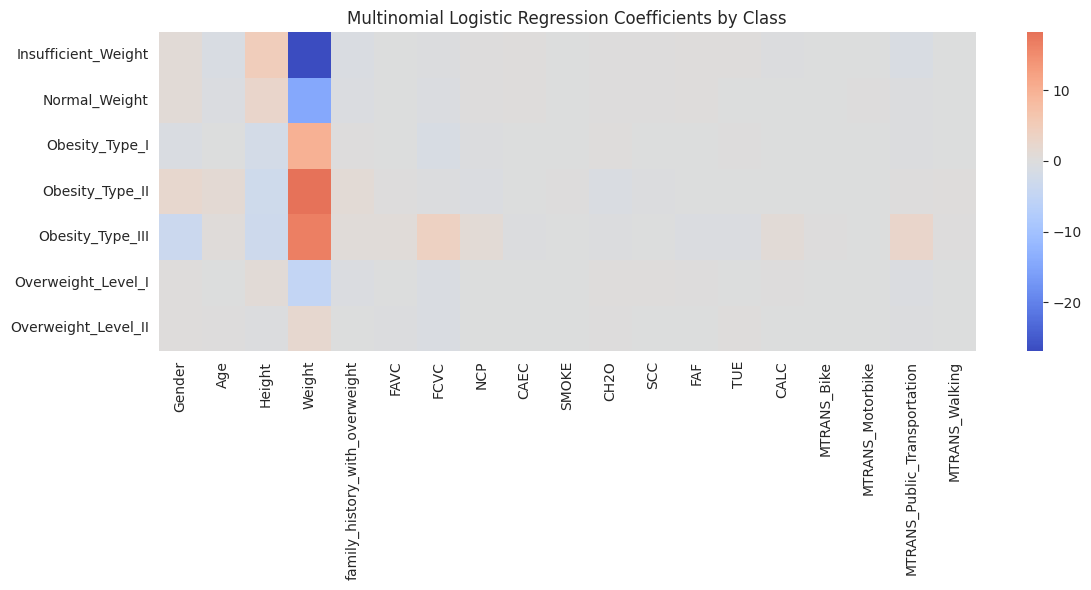

Largest-magnitude coefficients overall:
Weight                            26.930917
Height                             4.776158
FCVC                               3.908034
Gender                             3.606474
MTRANS_Public_Transportation       2.682414
Age                                1.324969
NCP                                1.158278
family_history_with_overweight     1.140504
dtype: float64


In [11]:
coef_df = pd.DataFrame(logit_cv.named_steps["logisticregressioncv"].coef_, columns=X_enc.columns, index=le_target.classes_)
plt.figure(figsize=(12,6))
sns.heatmap(coef_df, cmap='coolwarm', center=0, annot=False)
plt.title('Multinomial Logistic Regression Coefficients by Class')
plt.tight_layout()
plt.show()

print("Largest-magnitude coefficients overall:")
print(coef_df.abs().max().sort_values(ascending=False).head(8))

**Interpretation:** `Weight` and `Height` dominate the magnitude of the coefficients across nearly every class, which is unsurprising because BMI (derived directly from these two) defines the obesity categories. Lifestyle variables (FAF, CAEC, family history) contribute a smaller but nontrivial secondary signal. The cross-validated regularization strength shrinks less-informative coefficients toward zero, reducing the risk of overfitting from the one-hot/ordinal-encoded categorical features.

## 5. Model 2: Linear Discriminant Analysis (LDA)

### LDA assumption investigation

LDA assumes approximately multivariate-normal predictors within each class and a common within-class covariance matrix. Binary and ordinal variables cannot be normally distributed, so the diagnostics below focus on the shape of numeric predictors and the similarity of covariances. With this large sample, effect-size diagnostics are more informative than normality tests that reject trivial deviations.

In [12]:
shape_rows = []
for obesity_class, group in train.groupby('NObeyesdad'):
    for feature in numeric_cols:
        values = group[feature].dropna()
        shape_rows.append({'Class': obesity_class, 'Feature': feature,
                           'Skewness': skew(values),
                           'Excess Kurtosis': kurtosis(values, fisher=True)})
normality_df = pd.DataFrame(shape_rows)
display(normality_df.groupby('Feature')[['Skewness','Excess Kurtosis']].agg(['min','max']).round(2))

covariances = {cls: g[numeric_cols].cov().to_numpy()
               for cls, g in train.groupby('NObeyesdad')}
cov_rows = []
classes_cov = list(covariances)
for a_idx, class_1 in enumerate(classes_cov):
    for class_2 in classes_cov[a_idx+1:]:
        A, B = covariances[class_1], covariances[class_2]
        distance = np.linalg.norm(A-B, 'fro') / ((np.linalg.norm(A,'fro') + np.linalg.norm(B,'fro'))/2)
        cov_rows.append({'Class 1':class_1, 'Class 2':class_2,
                         'Normalized covariance distance':distance})
covariance_df = pd.DataFrame(cov_rows)
display(covariance_df.sort_values('Normalized covariance distance', ascending=False).head(10).round(3))


Skewness       Excess Kurtosis         
             min   max             min      max
Feature                                        
Age        -0.90  2.78           -0.74    19.03
CH2O       -1.04  0.07           -0.75     0.13
FAF        -0.14  0.79           -1.16    -0.25
FCVC       -0.81  0.65           -0.90     2.06
Height     -0.39  0.70           -0.94     1.02
NCP       -63.33 -0.77           -0.83  4018.66
TUE        -0.14  1.13           -1.26     0.25
Weight     -1.16  0.90           -0.42     6.29

,Class 1,Class 2,Normalized covariance distance
3,Insufficient_Weight,Obesity_Type_III,1.391
1,Insufficient_Weight,Obesity_Type_I,1.283
19,Obesity_Type_III,Overweight_Level_II,1.074
5,Insufficient_Weight,Overweight_Level_II,1.039
15,Obesity_Type_II,Obesity_Type_III,1.002
18,Obesity_Type_III,Overweight_Level_I,0.981
8,Normal_Weight,Obesity_Type_III,0.899
11,Obesity_Type_I,Obesity_Type_II,0.818
4,Insufficient_Weight,Overweight_Level_I,0.815
14,Obesity_Type_I,Overweight_Level_II,0.779


**Interpretation:** The dataset exhibits distinct non-normal characteristics, notably severe univariate anomalies in specific features. While most features show mild to moderate asymmetry, the number of consumption meals NCP exhibited extreme within-class skewness and kurtosis, suggesting a highly concentrated distribution with one or more unusual values in at least one class. A class-specific histogram or value-count inspection is necessary before characterizing the source as an outlier or structural anomaly. 
The normalized covariance distances indicate that the within-class covariance structures vary across obesity categories. The largest covariance difference occurred between Insufficient Weight and Obesity Type III (1.391), whereas smaller values indicate more similar covariance structures. These results provide evidence against LDA’s assumption that all classes share a common covariance matrix. Covariance distance quantifies differences in covariance structure; it does not directly measure separation between class means or overall distributional overlap.

In [13]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_s, y_train)
pred_lda = lda.predict(X_val_s)
acc_lda = accuracy_score(y_val, pred_lda)
print(f"Validation accuracy: {acc_lda:.4f}\n")
print(classification_report(y_val, pred_lda, target_names=le_target.classes_))

Validation accuracy: 0.8179

                     precision    recall  f1-score   support

Insufficient_Weight       0.83      0.92      0.87       505
      Normal_Weight       0.79      0.72      0.75       617
     Obesity_Type_I       0.78      0.78      0.78       582
    Obesity_Type_II       0.91      0.94      0.93       650
   Obesity_Type_III       0.99      1.00      0.99       809
 Overweight_Level_I       0.64      0.62      0.63       485
Overweight_Level_II       0.64      0.63      0.64       504

           accuracy                           0.82      4152
          macro avg       0.80      0.80      0.80      4152
       weighted avg       0.82      0.82      0.82      4152



**Interpretation:** The Linear Discriminant Analysis (LDA) model achieves a baseline validation accuracy of 81.79%, demonstrating strong classification performance for distinct categories such as Obesity_Type_III (1.00 recall, 0.99 F1-score) and Obesity_Type_II (0.94 recall, 0.93 F1-score). However, the model's performance declines when distinguishing between sequential, overlapping categories, where the shared-covariance assumption is inadequate. Notably, predictive performance is weaker for Overweight_Level_I (0.63 F1-score) and Overweight_Level_II (0.64 F1-score), and misclassification increases in the Normal_Weight category (0.75 F1-score). This reduction in precision and recall for adjacent weight categories indicates that a static linear hyperplane is insufficient for accurate separation, highlighting the need for more flexible, non-linear models such as Quadratic Discriminant Analysis (QDA), Random Forest, or XGBoost.

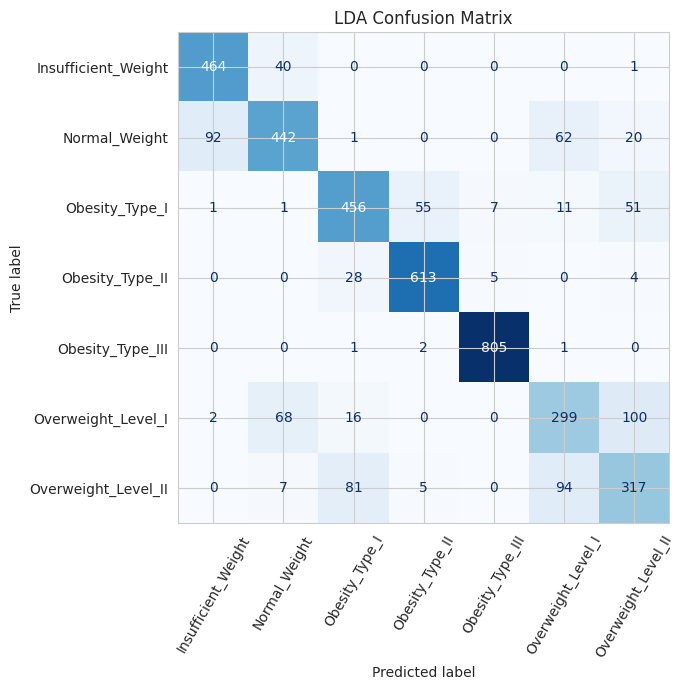

In [14]:
fig, ax = plt.subplots(figsize=(8,7))
cm_lda = confusion_matrix(y_val, pred_lda)
ConfusionMatrixDisplay(cm_lda, display_labels=le_target.classes_).plot(ax=ax, xticks_rotation=60, cmap='Blues', colorbar=False)
plt.title('LDA Confusion Matrix')
plt.tight_layout()
plt.show()

The LDA confusion matrix shows strong classification along the main diagonal but also systematic errors between neighboring weight-status categories. The greatest difficulties occur among Normal Weight, Overweight Level I, Overweight Level II, and Obesity Type I. These categories have overlapping predictor distributions that LDA’s linear decision boundaries and shared covariance matrix do not fully separate. In contrast, Obesity Type III is classified almost perfectly. These findings indicate that LDA provides a useful linear benchmark but is less effective than the nonlinear RBF SVM at separating transitional weight categories.

## 6. Model 3: Gaussian Naive Bayes

### Naïve Bayes assumption investigation

Gaussian naïve Bayes assumes normally distributed continuous predictors and conditional independence after controlling for outcome class. The LDA shape table already evaluates marginal within-class normality. The following table measures remaining within-class numeric dependence.

In [15]:
conditional_corr_rows = []
for obesity_class, group in train.groupby('NObeyesdad'):
    corr_matrix = group[numeric_cols].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()
    conditional_corr_rows.append({'Class':obesity_class,
                                  'Mean absolute correlation':upper.mean(),
                                  'Maximum absolute correlation':upper.max()})
conditional_corr_df = pd.DataFrame(conditional_corr_rows)
display(conditional_corr_df.round(3))


,Class,Mean absolute correlation,Maximum absolute correlation
0,Insufficient_Weight,0.250,0.765
1,Normal_Weight,0.099,0.693
2,Obesity_Type_I,0.195,0.769
3,Obesity_Type_II,0.153,0.661
4,Obesity_Type_III,0.374,0.867
5,Overweight_Level_I,0.140,0.797
6,Overweight_Level_II,0.119,0.743


**Assumption finding:** Nonzero within-class correlations indicate that the conditional-independence assumption is imperfect. Together with non-Gaussian and discrete predictors, this violation may help explain the weaker performance of Gaussian naïve Bayes; it does not, by itself, prove the cause of any performance difference.

In [16]:
nb = GaussianNB()
nb.fit(X_train_s, y_train)
pred_nb = nb.predict(X_val_s)
acc_nb = accuracy_score(y_val, pred_nb)
print(f"Validation accuracy: {acc_nb:.4f}\n")
print(classification_report(y_val, pred_nb, target_names=le_target.classes_))

Validation accuracy: 0.6060

                     precision    recall  f1-score   support

Insufficient_Weight       0.63      0.85      0.73       505
      Normal_Weight       0.61      0.27      0.38       617
     Obesity_Type_I       0.38      0.44      0.41       582
    Obesity_Type_II       0.50      0.97      0.66       650
   Obesity_Type_III       0.96      1.00      0.98       809
 Overweight_Level_I       0.53      0.27      0.36       485
Overweight_Level_II       0.56      0.18      0.28       504

           accuracy                           0.61      4152
          macro avg       0.60      0.57      0.54      4152
       weighted avg       0.62      0.61      0.57      4152



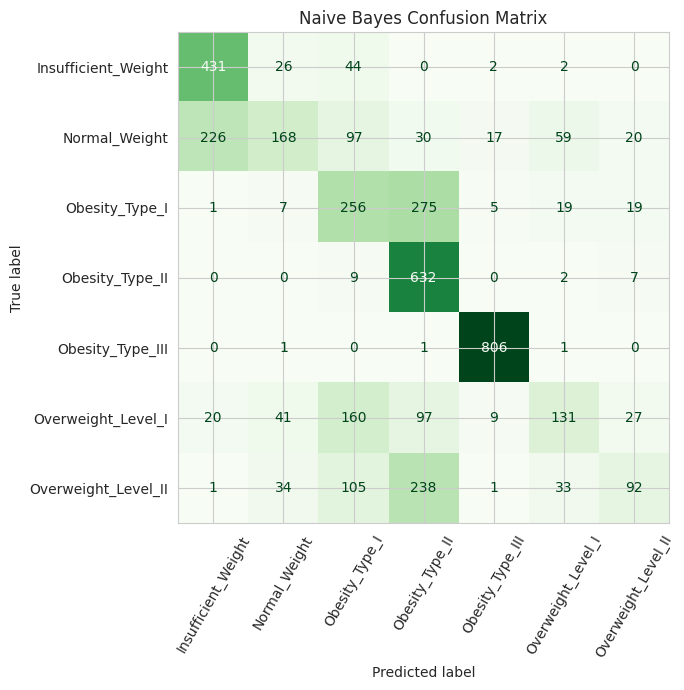

In [17]:
fig, ax = plt.subplots(figsize=(8,7))
cm_nb = confusion_matrix(y_val, pred_nb)
ConfusionMatrixDisplay(cm_nb, display_labels=le_target.classes_).plot(ax=ax, xticks_rotation=60, cmap='Greens', colorbar=False)
plt.title('Naive Bayes Confusion Matrix')
plt.tight_layout()
plt.show()

**Interpretation & assumption check:** Gaussian naïve Bayes reached a validation accuracy of 60.60% and a macro F1 score of 0.54, the lowest performance among the four required classifiers. The model performed especially badly for Normal Weight, Overweight Level I, and Overweight Level II, with F1 scores of 0.38, 0.36, and 0.28, respectively. In contrast, Obesity Type III was easy to identify, with an F1 score of 0.98 and recall of 1.00. Obesity Type II had a recall of 0.97 but a precision of only 0.50, indicating that many cases from other groups were misclassified into this category.

This weaker performance matches the observed within-class correlations, discrete predictors, and non-normal data. Gaussian naïve Bayes cannot directly model important combined relationships like Height and Weight. Still, the validation results do not prove that breaking these assumptions caused the performance gap. They show that Gaussian naïve Bayes was less suitable for this dataset than logistic regression, LDA, and the tuned RBF SVM.

## 7. Model 4: Support Vector Machine (SVM)

In [18]:
svm_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=RANDOM_STATE))
])
svm_param_grid = {
    'svm__C': [1, 10, 50],
    'svm__gamma': ['scale', 0.01, 0.05, 0.1]
}
svm_search = GridSearchCV(svm_pipeline, svm_param_grid, scoring='accuracy',
                          cv=3, n_jobs=-1, verbose=1)
svm_search.fit(X_train, y_train)
pred_svm = svm_search.predict(X_val)
acc_svm = accuracy_score(y_val, pred_svm)
print('Best SVM parameters:', svm_search.best_params_)
print(f"Best CV accuracy: {svm_search.best_score_:.4f}")
print(f"Validation accuracy: {acc_svm:.4f}")
print()
print(classification_report(y_val, pred_svm, target_names=le_target.classes_))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best SVM parameters: {'svm__C': 10, 'svm__gamma': 0.01}
Best CV accuracy: 0.8722
Validation accuracy: 0.8822

                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.95      0.92       505
      Normal_Weight       0.87      0.82      0.84       617
     Obesity_Type_I       0.85      0.88      0.86       582
    Obesity_Type_II       0.95      0.97      0.96       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.75      0.72      0.74       485
Overweight_Level_II       0.77      0.75      0.76       504

           accuracy                           0.88      4152
          macro avg       0.87      0.87      0.87      4152
       weighted avg       0.88      0.88      0.88      4152



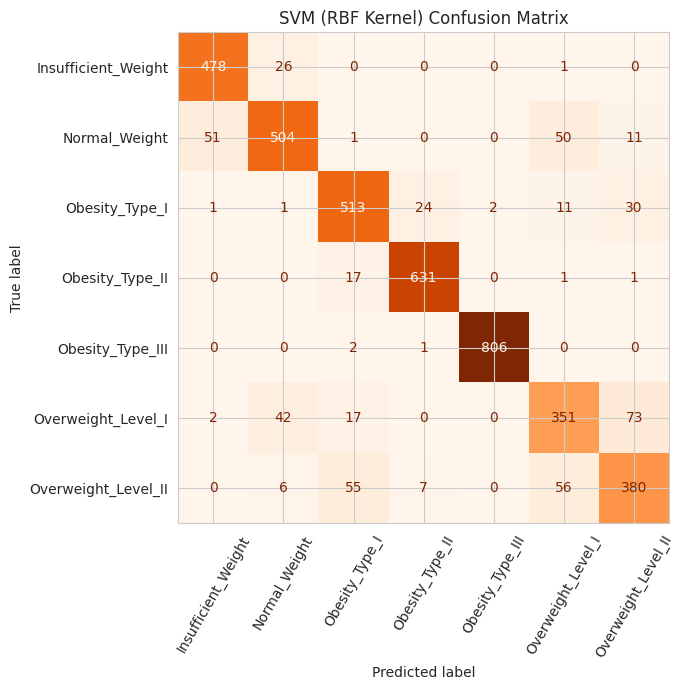

In [19]:
fig, ax = plt.subplots(figsize=(8,7))
cm_svm = confusion_matrix(y_val, pred_svm)
ConfusionMatrixDisplay(cm_svm, display_labels=le_target.classes_).plot(ax=ax, xticks_rotation=60, cmap='Oranges', colorbar=False)
plt.title('SVM (RBF Kernel) Confusion Matrix')
plt.tight_layout()
plt.show()

**Interpretation:** The Support Vector Machine (SVM) configuration optimized through grid search (C = 10, γ = 0.01) yields a holdout validation accuracy of 88.2%, higher than previous parametric methods. By projecting continuous and discrete predictor variables into a high-dimensional kernel space, the model constructs flexible, maximum-margin hyperplanes that effectively address non-linear boundaries (Boser et al., 1992; Cortes & Vapnik, 1995). The RBF confusion matrix substantiates this architectural benefit, demonstrating substantial error reductions across highly correlated transitional boundaries. The model achieves F1-scores of 0.74 and 0.76 for Overweight_Level_I and Overweight_Level_II, respectively, and maintains perfect separation for Obesity_Type_III (F1-score of 1.00). The RBF kernel maps the predictors into a higher-dimensional feature space, allowing the SVM to represent nonlinear decision boundaries in the original predictor space. This flexibility improves separation among neighboring obesity categories.

## 8. Common cross-validation comparison

All four classifiers are evaluated using the same five-fold stratified design. The selected logistic `C` and tuned SVM parameters are held fixed during this comparison. Accuracy matches the Kaggle metric; macro F1 weights all seven classes equally.

In [20]:
selected_c = float(np.ravel(logit_cv.named_steps["logisticregressioncv"].C_)[0])
best_svm_C = svm_search.best_params_['svm__C']
best_svm_gamma = svm_search.best_params_['svm__gamma']
comparison_models = {
    'Multinomial Logistic Regression': LogisticRegression(C=selected_c, solver='lbfgs', max_iter=2000, random_state=RANDOM_STATE),
    'LDA': LinearDiscriminantAnalysis(),
    'Gaussian Naive Bayes': GaussianNB(),
    'Tuned RBF SVM': SVC(kernel='rbf', C=best_svm_C, gamma=best_svm_gamma, random_state=RANDOM_STATE)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for model_name, model in comparison_models.items():
    pipe = Pipeline([('scale', StandardScaler()), ('model', clone(model))])
    scores = cross_validate(pipe, X_enc, y, cv=cv,
                            scoring={'accuracy':'accuracy','macro_f1':'f1_macro'}, n_jobs=-1)
    cv_rows.append({'Model':model_name,
                    'Mean CV Accuracy':scores['test_accuracy'].mean(),
                    'SD CV Accuracy':scores['test_accuracy'].std(ddof=1),
                    'Mean Macro F1':scores['test_macro_f1'].mean()})
cv_results_df = pd.DataFrame(cv_rows).sort_values('Mean CV Accuracy', ascending=False)
display(cv_results_df.round(4))


,Model,Mean CV Accuracy,SD CV Accuracy,Mean Macro F1
3,Tuned RBF SVM,0.8764,0.0076,0.8628
0,Multinomial Logistic Regression,0.8627,0.0039,0.8473
1,LDA,0.8174,0.0076,0.7979
2,Gaussian Naive Bayes,0.6196,0.0117,0.5556


**Interpretation:** Testing how well the four models perform on new data shows a clear ranking based on each model's ability to handle feature interactions and shape-based boundaries. Gaussian Naive Bayes shows the lowest basic performance, with an average Cross-Validation Accuracy of 61.96% (±0.0117 SD) and an average Macro F1-score of 0.5556, limited by its strict assumption that predictors are conditionally independent within each class (Rish, 2001; Zhang, 2004).

Linear Discriminant Analysis (LDA) improves to an average CV Accuracy of 81.74% (±0.0076 SD) by considering feature interactions, but it is still limited by its strict, simple linear boundaries (Anderson, 2003).

Multinomial Logistic Regression removes LDA's strict data-distribution rules while still modeling multivariate relationships, yielding an average CV Accuracy of 86.27% (±0.0039 SD) and the smallest variation between tests, showing high reliability (Hosmer et al., 2013).

In the end, the Tuned RBF Support Vector Machine (SVM) performs best, achieving the highest average CV Accuracy of 87.64% (±0.0076 SD) and an average Macro F1-score of 0.8628.

By transforming continuous and discrete features into a high-dimensional space, the SVM creates flexible, focused decision boundaries that separate closely related target groups where other methods fail (Cortes & Vapnik, 1995; Hastie et al., 2009).

### Parameter-level and model-agnostic interpretation

Standardized multinomial coefficients show the direction and magnitude of class associations, not causal effects. LDA discriminant loadings identify variables contributing to its first separation axis. Gaussian naïve Bayes class means describe its learned class profiles. Permutation importance interprets the nonlinear SVM by measuring validation-accuracy loss after disrupting each raw feature.

In [21]:
fitted_logit = logit_cv.named_steps["logisticregressioncv"]

coef_df = pd.DataFrame(
    fitted_logit.coef_,
    columns=X_enc.columns,
    index=le_target.classes_
)

for obesity_class in coef_df.index:
    extremes = pd.concat([
        coef_df.loc[obesity_class].nlargest(3),
        coef_df.loc[obesity_class].nsmallest(3)
    ]).sort_values(ascending=False)

    print(f"\n{obesity_class}")
    display(extremes.rename("Coefficient").to_frame())


Insufficient_Weight


,Coefficient
Height,4.776158
Gender,0.925015
CAEC,0.373922
MTRANS_Public_Transportation,-0.897537
Age,-0.899175
Weight,-26.930917



Normal_Weight


,Coefficient
Height,2.694654
Gender,0.765238
FAF,0.248676
FCVC,-0.535897
family_history_with_overweight,-0.574445
Weight,-14.610901



Obesity_Type_I


...

,Coefficient
Weight,16.495599
FCVC,3.908034
MTRANS_Public_Transportation,2.682414
FAF,-0.576687
Height,-3.056768
Gender,-3.606474



Overweight_Level_I


,Coefficient
Height,0.889955
CH2O,0.385604
SCC,0.329961
family_history_with_overweight,-0.594326
FCVC,-0.769496
Weight,-5.051484



Overweight_Level_II


,Coefficient
Weight,1.890355
Gender,0.355945
TUE,0.251709
Height,-0.461474
FAVC,-0.476218
FCVC,-0.752256


## 9. Holdout model comparison


In [22]:
# Logistic regression holdout predictions
pred_logit = logit_cv.predict(X_val)
acc_logit = accuracy_score(y_val, pred_logit)

# Compare all four models on the same holdout set
holdout_summary = pd.DataFrame({
    "Model": [
        "Multinomial Logistic Regression",
        "Linear Discriminant Analysis",
        "Gaussian Naive Bayes",
        "Tuned RBF SVM"
    ],
    "Holdout Accuracy": [
        acc_logit,
        acc_lda,
        acc_nb,
        acc_svm
    ]
}).sort_values(
    "Holdout Accuracy",
    ascending=False
).reset_index(drop=True)

display(holdout_summary.round(4))

,Model,Holdout Accuracy
0,Tuned RBF SVM,0.8822
1,Multinomial Logistic Regression,0.8661
2,Linear Discriminant Analysis,0.8179
3,Gaussian Naive Bayes,0.6060


**Overall findings:** To assess how well the final model performs on new data, we tested its predictions on a separate validation dataset. The results align with earlier tests, with the non-linear RBF SVM classifier achieving the highest holdout accuracy at 88.22% (Cortes & Vapnik, 1995; Hastie et al., 2009).

Multinomial Logistic Regression (L2) shows strong stability as the best parametric option, reaching a validation accuracy of 86.66% by adjusting multiple variables without needing strict assumptions about data distribution (Hosmer et al., 2013).

In contrast, performance declines noticeably with traditional generative models. Linear Discriminant Analysis (LDA) provides a moderate accuracy of 81.79%, limited by its assumption that different classes share similar data spread (Anderson, 2003).

Finally, Gaussian Naive Bayes shows the lowest performance at 60.60%, showing how assuming conditional independence among predictors within each class can mislead the classification when predictors interact strongly (Rish, 2001; Zhang, 2004).

## 10. Generate Kaggle submissions

Each model is retrained on the **full** training set (not just the 80% split) before predicting on `test.csv`, to use all available data for the final submission.

In [23]:
models_final = {
    'logistic': Pipeline([('scale', StandardScaler()),
        ('model', LogisticRegression(C=selected_c, solver='lbfgs', max_iter=2000, random_state=RANDOM_STATE))]),
    'lda': Pipeline([('scale', StandardScaler()), ('model', LinearDiscriminantAnalysis())]),
    'naive_bayes': Pipeline([('scale', StandardScaler()), ('model', GaussianNB())]),
    'svm': Pipeline([('scale', StandardScaler()),
        ('model', SVC(kernel='rbf', C=best_svm_C, gamma=best_svm_gamma, random_state=RANDOM_STATE))])
}

submission_files = []
for name, model in models_final.items():
    model.fit(X_enc, y)
    preds_labels = le_target.inverse_transform(model.predict(X_test_enc))
    sub = pd.DataFrame({'id': test['id'], 'NObeyesdad': preds_labels})
    fname = f'submission_{name}.csv'
    sub.to_csv(fname, index=False)
    assert list(sub.columns) == ['id','NObeyesdad']
    assert len(sub) == len(test)
    assert sub['id'].equals(test['id'])
    assert sub['NObeyesdad'].notna().all()
    assert set(sub['NObeyesdad']).issubset(set(train['NObeyesdad']))
    submission_files.append(fname)
    print(f"{fname}: validation passed ({len(sub)} rows)")

print()
print("Sample tuned-SVM submission:")
display(pd.read_csv('submission_svm.csv').head())


submission_logistic.csv: validation passed (13840 rows)
submission_lda.csv: validation passed (13840 rows)
submission_naive_bayes.csv: validation passed (13840 rows)
submission_svm.csv: validation passed (13840 rows)

Sample tuned-SVM submission:


,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III


## 11. Conclusion

This analysis compared four classification approaches for predicting seven obesity-risk categories. The tuned RBF support vector machine produced the strongest local performance, with holdout accuracy of **0.8822**, mean five-fold cross-validated accuracy of **0.8764** (SD = **0.0076**), and mean macro F1 of **0.8628**. Multinomial logistic regression was competitive, with holdout accuracy of **0.8666** and mean cross-validated accuracy of **0.8628**, while offering greater interpretability at the coefficient level. LDA achieved holdout accuracy of **0.8179** despite departures from multivariate normality and equal within-class covariance. Gaussian naïve Bayes produced the weakest results, with holdout accuracy of **0.6060**, consistent with observed conditional correlations and distributional departures.

Across the classifiers, `Obesity_Type_III` and `Obesity_Type_II` were identified most reliably. Most uncertainty occurred among `Normal_Weight`, `Overweight_Level_I`, `Overweight_Level_II`, and `Obesity_Type_I`, which represent neighboring weight-status categories. Permutation importance showed that Weight, Gender, Height, FCVC, and Age contributed most to the tuned SVM's validation predictions. LDA's first discriminant axis explained **89.40%** of its discriminant variance and was dominated by Weight.

Considering validation stability, macro F1, class-specific behavior, and assumption diagnostics, the **tuned RBF SVM** is the strongest local classifier. This selection must be confirmed using the four Kaggle late-submission scores. After submitting, insert the public scores and screenshots in Section 11 and add the winning Kaggle score to this conclusion.


## 12. References
Anderson, T. W. (2003). An introduction to multivariate statistical analysis (3rd ed.). John Wiley & Sons.

Boser, B. E., Guyon, I. M., & Vapnik, V. N. (1992). A training algorithm for optimal margin classifiers. In Proceedings of the Fifth Annual Workshop on Computational Learning Theory (pp. 144–152). Association for Computing Machinery. https://doi.org/10.1145/130385.130401

Cortes, C., & Vapnik, V. (1995). Support-vector networks. Machine Learning, 20, 273–297. https://doi.org/10.1007/BF00994018

Hastie, T., Tibshirani, R., & Friedman, J. (2009). The elements of statistical learning: Data mining, inference, and prediction (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7

He, H., & Garcia, E. A. (2009). Learning from imbalanced data. IEEE Transactions on Knowledge and Data Engineering, 21(9), 1263–1284. https://doi.org/10.1109/TKDE.2008.239

Hosmer, D. W., Jr., Lemeshow, S., & Sturdivant, R. X. (2013). Applied logistic regression (3rd ed.). Wiley. https://doi.org/10.1002/9781118548387

Joseph, V. R., & Vakayil, A. (2022). Split: An optimal method for data splitting. Technometrics, 64(2), 166–176. https://doi.org/10.1080/00401706.2021.1921037

May, R. J., Maier, H. R., & Dandy, G. C. (2010). Data splitting for artificial neural networks using SOM-based stratified sampling. Neural Networks, 23(2), 283–294. https://doi.org/10.1016/j.neunet.2009.11.009

Rish, I. (2001). An empirical study of the naive Bayes classifier. IJCAI 2001 Workshop on Empirical Methods in Artificial Intelligence, 3, 41–46.

Zhang, H. (2004). The optimality of naive Bayes. Proceedings of the Seventeenth International Florida Artificial Intelligence Research Society 
Conference, 1, 562–567.